<a href="https://colab.research.google.com/github/marioarsw/AnaliticaDescriptiva/blob/main/practicas/267379_02_semana11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Maestría en Inteligencia Artificial y Analítica de Datos


*   Curso: Programación para Analítica Descriptiva y Predictiva
*   Semestre: Enero-Junio
*   Profesor: Dr. Vicente García Jiménez

## Mario Amador - 267370.

** Regresión lineal con datos categóricos: Costos, Localidades y Salarios**

📌 Objetivos de la Práctica:
Al finalizar esta práctica, los estudiantes serán capaces de:

- Codificar variables categóricas usando one-hot encoding con K-1 para problemas de regresión
- Realizar AED
- Construir un modelo de regresión con variables dummy
- Interpretar los resultados de los coeficientes
- Analizar los resultados de los errores residuales
- Calcular el desempeño del modelo de regresión.

Problema: Se podría argumentar que el salario está relacionado con el costo de la educación. Por lo tanto, para analizar este argumentos veremos qué sucede cuando usamos las variables independientes cost y location.

# 1. Carga de datos

Carga el conjunto de datos college.csv, que está en campus virtual, en un dataframe. Elige de este conjunto las columnas salary (variable dependiente), cost(variable independiente - numérica) y location (variable independiente categórica).

Realiza lo siguiente:

*   Convierte si es necesario la variable location a tipo de dato categórico
*   Usa la instrucción describe() en las variables salary y cost
* Cuenta la cantidad de datos que hay por categoría en location
* Convierte la variable location usando one-hot encoding



In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score

In [22]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
df = pd.read_csv('/content/drive/MyDrive/ClassFiles/Unidad03/college.csv')

In [24]:
# Seleccionar únicamente las columnas necesarias
df = df[["salary", "cost", "location"]]

# Ver las primeras filas
print(df.head())

   salary    cost location
0  119000  189300       NE
1  121000  189600       NE
2  123000  188400       NE
3  123000  188700       NE
4  110000  194200       NE


In [25]:
# --------------------------------------------------
# Convertir location a tipo categórico
# --------------------------------------------------
df["location"] = df["location"].astype("category")

print("\nTipo de dato de location:")
print(df["location"].dtype)


Tipo de dato de location:
category


In [26]:
# --------------------------------------------------
# describe() para salary y cost
# --------------------------------------------------
print("\nDescripción estadística de salary:")
print(df["salary"].describe())

print("\nDescripción estadística de cost:")
print(df["cost"].describe())


Descripción estadística de salary:
count        85.000000
mean      95898.823529
std       11937.121912
min       74900.000000
25%       87100.000000
50%       93200.000000
75%      105000.000000
max      123000.000000
Name: salary, dtype: float64

Descripción estadística de cost:
count        85.000000
mean     142434.470588
std       53913.064578
min       18260.000000
25%       84670.000000
50%      169200.000000
75%      188700.000000
max      227300.000000
Name: cost, dtype: float64


In [27]:
# --------------------------------------------------
# Contar cantidad de datos por categoría en location
# --------------------------------------------------
print("\nCantidad de datos por categoría en location:")
print(df["location"].value_counts())


Cantidad de datos por categoría en location:
location
NE    25
W     21
S     20
MW    19
Name: count, dtype: int64


In [28]:
# --------------------------------------------------
# One-Hot Encoding de location (K-1)
# drop_first=True evita multicolinealidad
# --------------------------------------------------
df_encoded = pd.get_dummies(df, columns=["location"], drop_first=True)

print("\nDataFrame después de One-Hot Encoding:")
print(df_encoded.head())


DataFrame después de One-Hot Encoding:
   salary    cost  location_NE  location_S  location_W
0  119000  189300         True       False       False
1  121000  189600         True       False       False
2  123000  188400         True       False       False
3  123000  188700         True       False       False
4  110000  194200         True       False       False


# 2. Análisis Exploratorio de los Datos

Realiza un análisis exploratorio de los datos y discute lo que observas en cada gráfica.


*   Crea un histograma de la columna salary. Discute lo que observas
* Crea un diagrama de dispersión de salary vs cost, considerando lo siguiente: para cada punto elegirás un color que represente la localidad en la que está el salario y el costo de la educación. Por lo tanto el diagrama de dispersión debería tener puntos en 4 colores distintos. Discute lo que observas
* Emplea un boxplot para saber si hay diferencias en los costos según la ubicación, es decir, con boxplot deberás analizar la distribución de cost por localidad. Discute lo que observas




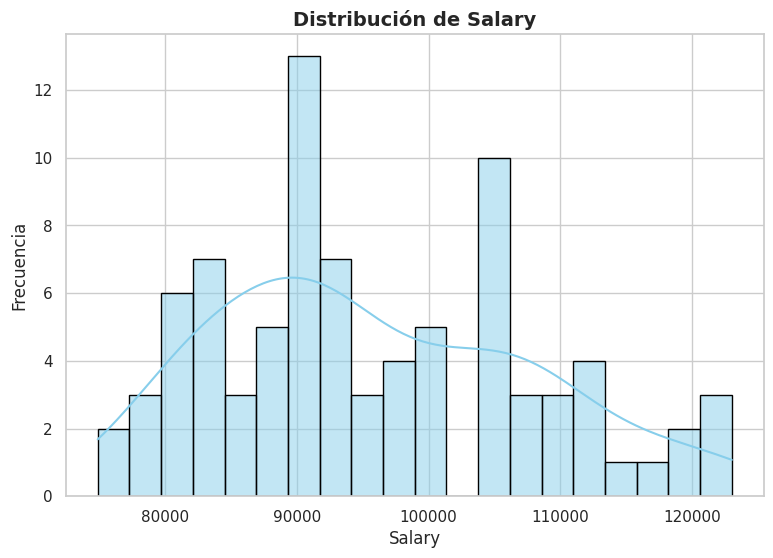

In [29]:
# --------------------------------------------------
# 1. Histograma de salary
# --------------------------------------------------
sns.set(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (9,6)

plt.figure()
sns.histplot(
    data=df,
    x="salary",
    bins=20,
    kde=True,
    color="skyblue",
    edgecolor="black"
)

plt.title("Distribución de Salary", fontsize=14, fontweight="bold")
plt.xlabel("Salary")
plt.ylabel("Frecuencia")
plt.show()

Se observa que la distribución de los salarios no es completamente uniforme, sino que existe una mayor concentración entre los 85,000 y 105,000 aproximadamente. Esto indica que la mayoría de los egresados se encuentran dentro de ese rango salarial.

También se aprecia una ligera asimetría hacia la derecha, lo que sugiere que existen algunos valores altos de salario (por encima de 115,000), aunque son menos frecuentes. Esto indica la presencia de algunas universidades cuyos egresados logran salarios considerablemente superiores al promedio.

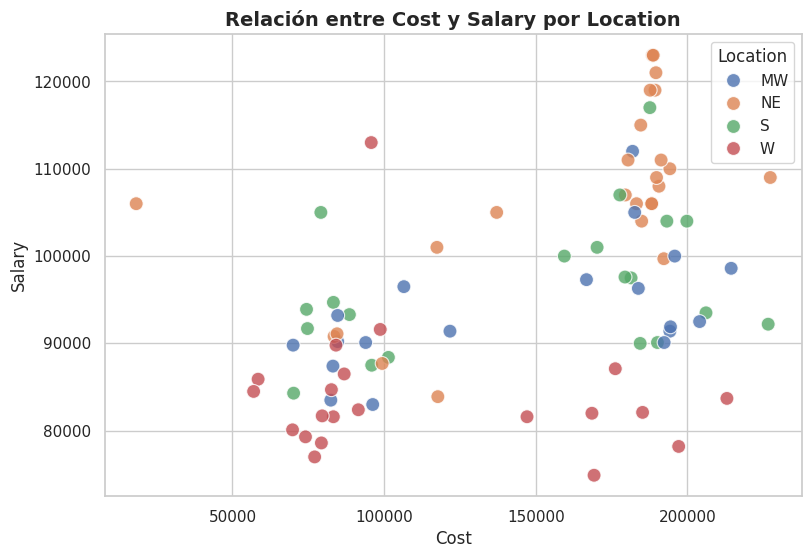

In [30]:
# --------------------------------------------------
# 2. Diagrama de dispersión salary vs cost
# con colores por location
# --------------------------------------------------
plt.figure()
sns.scatterplot(
    data=df,
    x="cost",
    y="salary",
    hue="location",
    palette="deep",
    s=100,
    alpha=0.8
)

plt.title("Relación entre Cost y Salary por Location", fontsize=14, fontweight="bold")
plt.xlabel("Cost")
plt.ylabel("Salary")
plt.legend(title="Location")
plt.show()


Se puede observar una relación positiva moderada entre el costo de la educación y el salario, es decir, conforme aumenta el costo de estudiar, en varios casos también aumenta el salario esperado.

Sin embargo, esta relación no es perfecta, ya que existen instituciones con costos altos pero salarios relativamente bajos, especialmente en la región W.

La región NE parece concentrar varios de los salarios más altos junto con costos elevados, lo que podría sugerir una mejor relación entre inversión educativa y retorno salarial. En cambio, W presenta varios costos altos pero salarios más bajos, lo que podría indicar menor eficiencia en esa relación.

/tmp/ipykernel_8204/4026304085.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


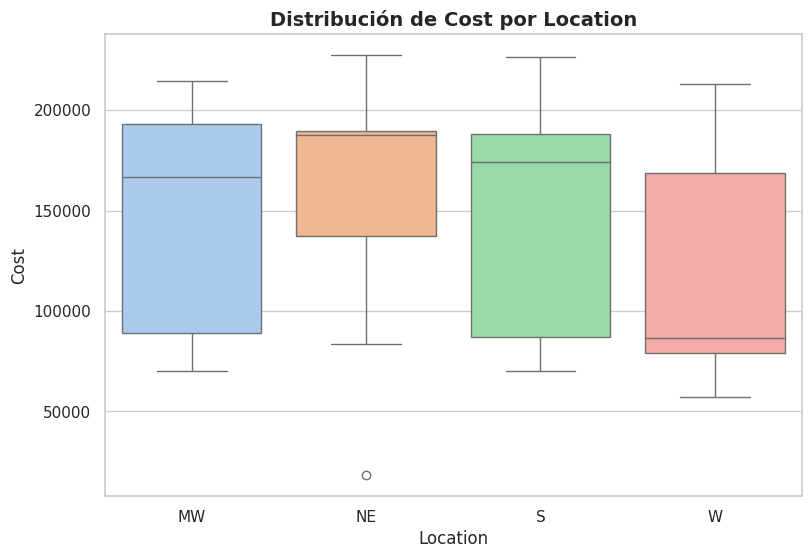

In [31]:
# --------------------------------------------------
# 3. Boxplot bonito de cost por location
# --------------------------------------------------
plt.figure()
sns.boxplot(
    data=df,
    x="location",
    y="cost",
    palette="pastel"
)

plt.title("Distribución de Cost por Location", fontsize=14, fontweight="bold")
plt.xlabel("Location")
plt.ylabel("Cost")
plt.show()

El boxplot muestra diferencias claras en los costos según la ubicación.

Las regiones MW, NE y S presentan medianas de costo relativamente altas y bastante similares entre sí, mientras que W muestra una mediana considerablemente más baja.

Además, NE presenta un valor atípico muy bajo, lo que indica una institución con costo mucho menor al resto de su región.

También se observa que algunas regiones tienen mayor dispersión en los costos, especialmente MW y S, lo que significa que dentro de esas localidades existe mayor variabilidad en los precios de educación.

En general, la ubicación sí parece influir en el costo educativo, lo cual justifica su uso como variable explicativa dentro del modelo de regresión.

# 3. Construcción del modelo de regresión

- Construye el modelo de regresión usando los datos de salario, costo y location. Recuerda que esta última debe ser en su versión codificada con one-hot encoding.
- Imprime los coeficientes e interpreta qué significan cuando se sustituyen valores en costo, y location (versión codificada). Si no recuerdas cómo se hace esta interpretación consulta los videos.


In [35]:
# --------------------------------------------------
# Variables independientes (X) y dependiente (y)
# --------------------------------------------------
X = df_encoded.drop("salary", axis=1)
y = df_encoded["salary"]

# Convertir todo a numérico
X = X.astype(float)
y = y.astype(float)

# Agregar constante (intercepto)
X = sm.add_constant(X)

# --------------------------------------------------
# Construcción del modelo de regresión
# --------------------------------------------------
modelo = sm.OLS(y, X).fit()

# --------------------------------------------------
# Resumen del modelo
# --------------------------------------------------
print(modelo.summary())

# --------------------------------------------------
# Coeficientes
# --------------------------------------------------
print("\nCoeficientes del modelo:")
print(modelo.params)

                            OLS Regression Results                            
Dep. Variable:                 salary   R-squared:                       0.571
Model:                            OLS   Adj. R-squared:                  0.549
Method:                 Least Squares   F-statistic:                     26.57
Date:                Fri, 24 Apr 2026   Prob (F-statistic):           4.96e-14
Time:                        18:02:18   Log-Likelihood:                -882.12
No. Observations:                  85   AIC:                             1774.
Df Residuals:                      80   BIC:                             1786.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        8.499e+04   3092.655     27.481      

## Interpretación de los coeficientes

### El modelo obtenido fue:

$$Salary = 84988.72+0.0605(Cost)+12032.82(Location_{NE})+2800.35(Location_S)−7721.42(Location_W)$$

La categoría base (la que se eliminó en el One-Hot Encoding) es MW, por lo tanto todas las comparaciones de location se hacen respecto a esa región.

### Intercepto (const = 84,988.72)

Este valor representa el salario estimado cuando:

* el costo de educación es 0
* la universidad pertenece a la categoría base (MW)

Aunque en la práctica un costo de 0 no es realista, el intercepto sirve como punto de partida del modelo.

### Coeficiente de cost (0.0605)

Este coeficiente indica que por cada 1 adicional en el costo de educación, el salario esperado aumenta en aproximadamente 0.0605, manteniendo constante la ubicación.

Por ejemplo, si el costo aumenta en $10,000:

0.0605×10000=605

Entonces el salario esperado aumentaría aproximadamente $605.

Esto muestra una relación positiva entre costo educativo y salario.

### Coeficiente de location_NE (12,032.82)

Si la universidad está en la región NE, el salario esperado aumenta en aproximadamente $12,032.82 respecto a la región base (MW), manteniendo constante el costo.

Esto sugiere que estudiar en NE tiene una fuerte asociación positiva con salarios más altos.

Además, su p-value es muy pequeño (0.000), por lo que esta variable sí resulta estadísticamente significativa.

### Coeficiente de location_S (2,800.35)

Si la universidad está en la región S, el salario esperado aumenta en aproximadamente $2,800.35 respecto a MW.

Sin embargo, su p-value es 0.279, lo que indica que esta diferencia no es estadísticamente significativa.

Esto significa que no hay suficiente evidencia para afirmar que S sea diferente de MW en términos salariales.

### Coeficiente de location_W (-7,721.42)

Si la universidad está en la región W, el salario esperado disminuye en aproximadamente $7,721.42 respecto a MW, manteniendo constante el costo.

Esto indica una relación negativa entre esta ubicación y el salario esperado.

Además, su p-value es 0.004, por lo que sí es estadísticamente significativa.

### Ejemplo de sustitución

Supongamos:

* Cost = 150,000
* Location = NE

Entonces:

* location_NE = 1
* location_S = 0
* location_W = 0

Sustituyendo:

$$Salary = 84988.72+0.0605(150000)+12032.82$$

$$Salary = 84988.72+9075+12032.82$$

$$Salary = 106096.54$$

El salario estimado sería aproximadamente $106,097.

### Interpretación general del modelo

El modelo explica aproximadamente el 57.1% de la variabilidad del salario (R² = 0.571), lo cual indica un ajuste moderado.

Las variables más importantes parecen ser:

* cost
* location_NE
* location_W

mientras que location_S no muestra una influencia significativa.

# 4. Análisis de Residuos

- Construyen una visualización de predicciones (salario estimado) vs valores reales (salario real).
- Crea una gráfica de los errores residuales. Discute lo que observas

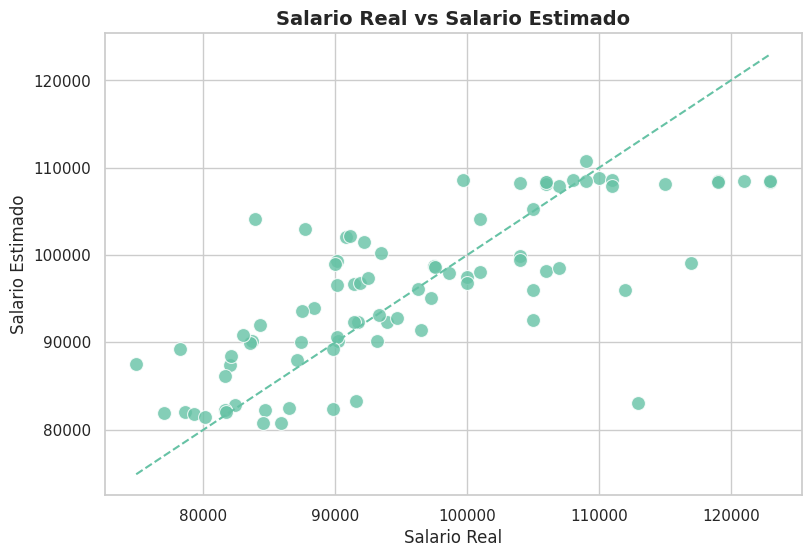

In [36]:
# --------------------------------------------------
# Predicciones del modelo
# --------------------------------------------------
y_pred = modelo.predict(X)

# Residuos
residuos = y - y_pred


# --------------------------------------------------
# 1. Gráfica: valores reales vs valores predichos
# --------------------------------------------------
plt.figure(figsize=(9,6))

sns.scatterplot(
    x=y,
    y=y_pred,
    s=100,
    alpha=0.8
)

# Línea ideal (predicción perfecta)
plt.plot(
    [y.min(), y.max()],
    [y.min(), y.max()],
    linestyle="--"
)

plt.title("Salario Real vs Salario Estimado", fontsize=14, fontweight="bold")
plt.xlabel("Salario Real")
plt.ylabel("Salario Estimado")
plt.show()

### Gráfica de Salario Real vs Salario Estimado

En esta gráfica se observa que una buena parte de los puntos se encuentra relativamente cerca de la línea diagonal, lo que indica que el modelo logra predecir de forma razonable los salarios reales.

Sin embargo, también existen varios puntos alejados de esta línea, especialmente en salarios más altos, lo que muestra que el modelo no explica perfectamente todos los casos. Esto confirma que el ajuste del modelo es moderado y coincide con el valor de R
2
=0.571, donde aproximadamente el 57.1% de la variabilidad del salario es explicada por las variables cost y location.

También se aprecia que en algunos casos el modelo tiende a subestimar salarios altos y sobreestimar algunos salarios bajos, lo que sugiere que podrían existir otras variables importantes no incluidas en el modelo.

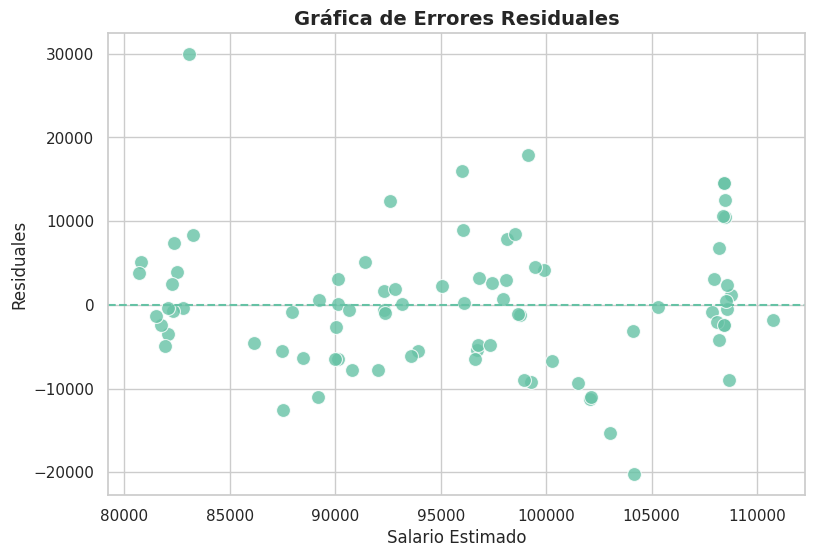

In [37]:
# --------------------------------------------------
# 2. Gráfica de residuos
# --------------------------------------------------
plt.figure(figsize=(9,6))

sns.scatterplot(
    x=y_pred,
    y=residuos,
    s=100,
    alpha=0.8
)

# Línea horizontal en cero
plt.axhline(y=0, linestyle="--")

plt.title("Gráfica de Errores Residuales", fontsize=14, fontweight="bold")
plt.xlabel("Salario Estimado")
plt.ylabel("Residuales")
plt.show()

### Gráfica de Errores Residuales

Los residuos se encuentran distribuidos alrededor de la línea horizontal en cero, lo cual es una buena señal, ya que indica que el modelo no presenta un sesgo sistemático fuerte.

No obstante, se observan algunos residuos bastante grandes, tanto positivos como negativos, lo que indica la presencia de observaciones atípicas donde el modelo falla considerablemente en la predicción.

También puede notarse cierta dispersión variable en algunos rangos, especialmente entre los salarios estimados de 95,000 a 105,000, lo que podría sugerir una ligera heterocedasticidad (la varianza de los errores no es completamente constante).

Aun así, no se observa un patrón curvo muy marcado, por lo que el supuesto de linealidad parece cumplirse de manera aceptable.

# 5. Evalúa el modelo

- Calcula el MSE del modelo construido. Recuerda que usas el propio conjunto de datos (No hablamos nada de entrenamiento y test).
- Calcula el R² Score

Discute estos resultados obtenidos.

In [38]:
# --------------------------------------------------
# Predicciones del modelo
# --------------------------------------------------
y_pred = modelo.predict(X)

# --------------------------------------------------
# Cálculo del MSE
# --------------------------------------------------
mse = mean_squared_error(y, y_pred)

# --------------------------------------------------
# Cálculo del R² Score
# --------------------------------------------------
r2 = r2_score(y, y_pred)

# --------------------------------------------------
# Mostrar resultados
# --------------------------------------------------
print("MSE del modelo:", mse)
print("R² Score del modelo:", r2)

MSE del modelo: 60480269.14657192
R² Score del modelo: 0.5705089716684084


### Observación del MSE

El MSE obtenido fue de 60,480,269.15, lo que indica que aún existen diferencias considerables entre los salarios reales y los estimados por el modelo. Esto sugiere que, aunque el modelo predice de forma aceptable, todavía presenta errores importantes en algunas observaciones.

### Observación del R² Score

El R² fue de 0.5705, lo que significa que el modelo explica aproximadamente el 57% de la variación del salario. Esto representa un ajuste moderado, por lo que las variables cost y location sí influyen en salary, aunque todavía faltan otros factores importantes por considerar.

# 6. Realiza un análisis de varianza con stastmodel

Consulta esto aquí https://www.statsmodels.org/dev/examples/notebooks/generated/variance_components.html

In [41]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# --------------------------------------------------
# Modelo ANOVA
# --------------------------------------------------
modelo_anova = ols('salary ~ C(location)', data=df).fit()

# --------------------------------------------------
# Tabla ANOVA
# --------------------------------------------------
anova_resultado = sm.stats.anova_lm(modelo_anova, typ=2)

print(anova_resultado)

                   sum_sq    df          F        PR(>F)
C(location)  6.040930e+09   3.0  27.511391  2.286810e-12
Residual     5.928639e+09  81.0        NaN           NaN


### Interpretación del análisis de varianza (ANOVA)

En la tabla ANOVA se obtuvo:

* F = 27.51
* p-value = 2.286810e-12

El valor más importante es el p-value (PR(>F)), ya que nos permite determinar si existen diferencias significativas entre los salarios según la ubicación (location).

Como:

p < 0.05

se rechaza la hipótesis nula *(H0)*, la cual establece que no existen diferencias entre los salarios promedio de las distintas localidades.

Por lo tanto, se concluye que la variable location sí tiene un efecto significativo sobre salary, es decir, la ubicación geográfica influye de manera importante en el salario.

Además, el valor de F relativamente alto (27.51) refuerza esta conclusión, indicando que la variabilidad entre grupos (localidades) es mucho mayor que la variabilidad dentro de los grupos.

### Conclusión

Existe evidencia estadística suficiente para afirmar que los salarios promedio cambian según la ubicación de la universidad. Esto justifica que la variable *location* haya sido incluida dentro del modelo de regresión como una variable explicativa importante.